tuple throughput
4    3246.270
5    3575.130
0    3633.330
1    3686.530
2    3708.870
3     911.067
Name: throughput_txn_per_sec, dtype: float64
0     564.00
5    1641.87
1    2871.60
2    3146.53
3    3429.60
4     865.20
Name: throughput_txn_per_sec, dtype: float64
a
4    3246.270
5    3575.130
0    3633.330
1    3686.530
2    3708.870
3     911.067
Name: throughput_txn_per_sec, dtype: float64
0     564.00
5    1641.87
1    2871.60
2    3146.53
3    3429.60
4     865.20
Name: throughput_txn_per_sec, dtype: float64


/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ndim = x[:, None].ndim
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


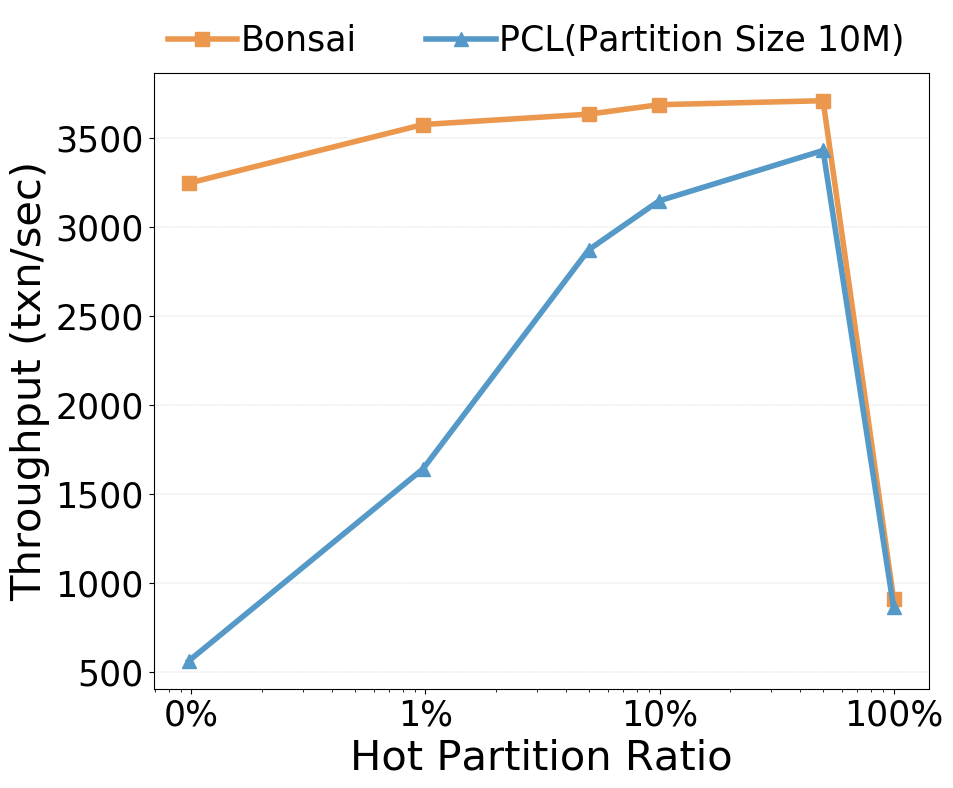

In [2]:
from process_helper import *
import numpy as np

# _, grad_colors = display_colors()
# _, bar_colors = select_color_idx(4)
color_indices, line_colors = select_color_idx(4)
txtsize=30
ticksize=25
plt.rcParams.update({'font.size': 15})
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 0.5
# idxs = ["g_total_buf_sz", "read_perc_","g_total_buf_sz"]
datadir = "../../output/"
exp_next_key = "exp_mix_bonsai_varying_working_set"
exp_partition_lock = "exp_mix_pcl_varying_working_set"

data_next_key = [json.loads(line) for line in open(datadir + exp_next_key + ".txt")]
df_next_key = pd.DataFrame().from_records(data_next_key)
# only get result for cache size 0.75
df_next_key = apply_mask(df_next_key, [
    ["g_total_buf_sz", ["eq", 9000000000]]
])

df_next_key = df_next_key.sort_values(by='g_workingset_partition_num')

data_partition_lock = [json.loads(line) for line in open(datadir + exp_partition_lock + ".txt")]
df_partition_lock = pd.DataFrame().from_records(data_partition_lock)
df_partition_lock = apply_mask(df_partition_lock, [
    ["g_total_buf_sz", ["eq", 9000000000]]
])


df_partition_lock = df_partition_lock.sort_values(by='g_workingset_partition_num')

# print(df_tuple)
fig = plt.figure(figsize=(10, 8))

# fig, ax = plt.subplots()
ax = fig.add_subplot(1, 1, 1)

print("tuple throughput")
print(df_next_key["throughput_txn_per_sec"])
print(df_partition_lock["throughput_txn_per_sec"])
single_value = df_next_key["throughput_txn_per_sec"].iloc[0]
repeat_count = len(df_partition_lock["g_workingset_partition_num"])
    
tuple_throughput = np.repeat(single_value, repeat_count)

ticks = np.array(df_partition_lock["g_workingset_partition_num"]/1024.0 * 100)
# print("hah")
# print(df_partition_lock["g_workingset_partition_num"])
# print(ticks)
x_tick_labels = [f"{num}%" for num in ticks]

line_width= 4
ms = 10
ax.plot(ticks, 
         df_next_key["throughput_txn_per_sec"],
        color=line_colors["ORANGE"],
        marker="s", markersize=ms, linewidth=line_width, label="Bonsai")

ax.plot(ticks, 
        df_partition_lock["throughput_txn_per_sec"],
        color=line_colors["BLUE"],
        marker="^", markersize=ms, linewidth=line_width,  label="PCL(Partition Size 10M)")

print("a")
print(df_next_key["throughput_txn_per_sec"])
print(df_partition_lock["throughput_txn_per_sec"])

# ax.set_ylim(0, 2000)
#ax.set_xlim(0, 1)
# print(df_partition_lock["g_partition_covering_lock_unit_sz"]/1000)

# ax.set_xticks(ticks, x_tick_labels)
# plt.xticks(ticks,x_tick_labels)
# ax.set_xlim([ticks.min() - 1, ticks.max() + 1])
ax.set_xscale('log')
# ax.set_yscale('log')
location = "best"
ax.legend(loc=location, frameon=False)
ax.set_ylabel("Throughput (txn/sec)", fontsize=txtsize)
ax.set_xlabel("Hot Partition Ratio", fontsize=txtsize)
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
# ax.set_title("Throughput Varying Partition Size (buffer 0.75, 25% RW Txn ratio)")
xticks = ax.get_xticks()  # Get current ticks
# Filter out non-positive values, format them with the "%" symbol, and set them as new labels
ax.set_xticklabels([f"{int(label)}%" for label in xticks if label > 0])
plt.tick_params(axis='both', labelsize=ticksize)
# legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
#            ncol=2,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.9, frameon=False)
legend = plt.legend(fontsize=ticksize, bbox_to_anchor=(0.0, 1.0, 1.1, .102), loc=2,
           ncol=2,borderaxespad=0., frameon=False,columnspacing=2, handletextpad=0.1)
# for line in legend.get_lines():
#     line.set_linewidth(10)  # Set your desired linewidth
# ax.set_title("Throughput Varying Buffer Size (theta 0.9, writeheavy)")
plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev2-scan-pathological-exp.pdf",bbox_inches='tight')


/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ndim = x[:, None].ndim
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


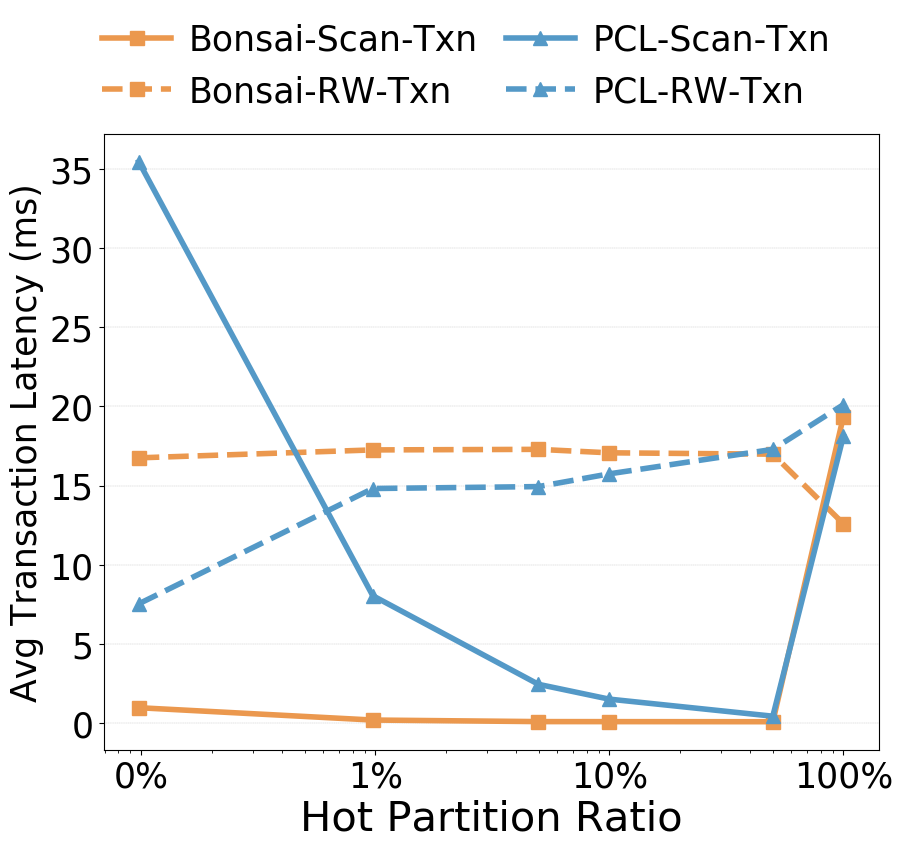

In [3]:
from matplotlib.patches import Patch
fig = plt.figure(figsize=(10, 8))
bonsai_c = "#ea801c"
# page_retain_c = "#2066a8" 
# page_evict_c = "#3594cc"

page_retain_c = "#31a354" 
page_evict_c = "#78c679"

tt_retain_c = "#1f6f6f"
tt_evict_c = "#54a1a1" 
bonsai_line = "s"
page_line = "^"
tt_line = "o"

ax= fig.add_subplot(1, 1, 1)
bar_width = 0.4
ticks = np.array(df_partition_lock["g_workingset_partition_num"]/1024.0 * 100)
# index = np.arange(len(ticks))
index = ticks


line_width = 4
ms = 10

ax.plot(index, 
        df_next_key["avg_sum_scan_txn_latency (us)"]/1000,
        color=line_colors["ORANGE"], markersize= ms,linewidth=line_width,
        marker="s", label="Bonsai-Scan-Txn")
ax.plot(index, 
        # df_tuple["txn_latency_perc99_us"]/1000,
         df_next_key["avg_sum_rw_txn_latency (us)"]/1000,
        color=line_colors["ORANGE"], markersize= ms,linewidth=line_width,
        marker="s", label="Bonsai-RW-Txn", linestyle='dashed')


ax.plot(index, 
    # df_tuple["txn_latency_perc99_us"]/1000,
        df_partition_lock["avg_sum_scan_txn_latency (us)"]/1000,
        color=line_colors["BLUE"], markersize= ms,linewidth=line_width,
        marker="^", label="PCL-Scan-Txn")

# # # # Annotate each data point with its corresponding value
# # # for i in range(len(df_page["g_total_buf_sz"])):
# # #     plt.annotate(f'{df_page["throughput_txn_per_sec"][i]:.2f}', (df_page["g_total_buf_sz"][i], df_page["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

ax.plot(index, 
    # df_page_idx_evict["txn_latency_perc99_us"]/1000,
        df_partition_lock["avg_sum_rw_txn_latency (us)"]/1000,
        color=line_colors["BLUE"], markersize= ms,linewidth=line_width,
        marker="^", label="PCL-RW-Txn", linestyle='dashed')

# ax.set_ylim(0, 125)
#ax.set_xlim(0, 1)
# ax.set_xticks(df_next_key["zipf_theta_"])
# plt.xticks(index,ticks)
plt.xticks(ticks)
ax.set_xscale('log')
# ax.set_yscale('log')
xticks = ax.get_xticks()  # Get current ticks
# Filter out non-positive values, format them with the "%" symbol, and set them as new labels
ax.set_xticklabels([f"{int(label)}%" for label in xticks if label > 0])
location = "best"
# ax.legend(loc=location, frameon=False)
legend = ax.legend(fontsize=ticksize, bbox_to_anchor=(-0.02, 1.1, 1.1, .102), loc=2,
           ncol=2,borderaxespad=0., frameon=False,columnspacing=0.8, handletextpad=0.5)
ax.set_ylabel("Avg Transaction Latency (ms)", fontsize=ticksize)
# ax.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
ax.set_xlabel("Hot Partition Ratio", fontsize=txtsize)
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax.tick_params(axis='both', labelsize=ticksize)
plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev2-scan-pathological-exp-latency.pdf",bbox_inches='tight')

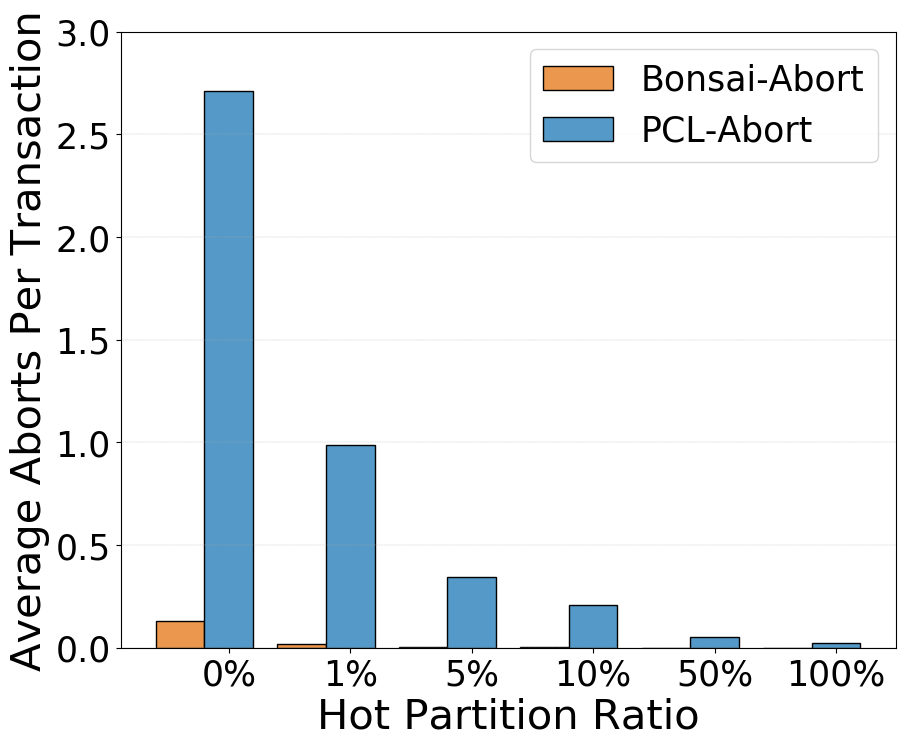

In [4]:
from matplotlib.patches import Patch
fig = plt.figure(figsize=(10, 8))
bonsai_c = "#ea801c"
# page_retain_c = "#2066a8" 
# page_evict_c = "#3594cc"

page_retain_c = "#31a354" 
page_evict_c = "#78c679"

tt_retain_c = "#1f6f6f"
tt_evict_c = "#54a1a1" 
bonsai_line = "s"
page_line = "^"
tt_line = "o"

ax1 = fig.add_subplot(1, 1, 1)
bar_width = 0.4
# ticks = np.array(df_partition_lock["g_partition_covering_lock_unit_sz"])/1000
ticks = np.array(df_partition_lock["g_workingset_partition_num"]/1024.0 * 100)
ticks = np.around(ticks).astype(int)
x_tick_labels = [f"{num}%" for num in ticks]


index = np.arange(len(ticks))

ax1.bar(index + 1 * bar_width, 
        df_next_key["abort_cnt_"]/df_next_key["txn_cnt_"] , width=bar_width,edgecolor='black',  
        color=line_colors["ORANGE"],
        label="Bonsai-Abort")



ax1.bar(index + 2 * bar_width, 
        df_partition_lock["abort_cnt_"]/df_partition_lock["txn_cnt_"] , width=bar_width,edgecolor='black',
        color=line_colors["BLUE"],
        label="PCL-Abort")

ax1.tick_params(axis='both', labelsize=ticksize)
plt.xticks(index + bar_width * (5 - 1) / 2,x_tick_labels)
# location = "upper left"
location = "best"
ax1.legend(loc=location, fontsize=ticksize)
ax1.set_ylabel("Average Aborts Per Transaction",fontsize=txtsize)
ax1.set_xlabel("Hot Partition Ratio",fontsize=txtsize)
ax1.set_ylim(0.0,3.0)
# ax1.set_xscale('log')
# ax1.set_title("Txn Abort Ratio(buffer 1.25, 25% RW Txn ratio)")
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)

plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev2-scan-pathological-exp-abort.pdf",bbox_inches='tight')

